# Medidas de posição e disperção

## Base de dados

In [115]:
import pandas as pd
import numpy as np
import statistics
from scipy import stats
import math

In [116]:
dados = np.array([150, 151, 152, 152, 153, 154, 155, 155, 155, 155, 156, 156, 156,
       157, 158, 158, 160, 160, 160, 160, 160, 161, 161, 161, 161, 162,
       163, 163, 164, 164, 164, 165, 166, 167, 168, 168, 169, 170, 172,
       173])

## Média aritmética simples

In [117]:
dados.sum() / len(dados)
dados.mean()
statistics.mean(dados)

np.int64(160)

## Moda

In [118]:
statistics.mode(dados)
stats.mode(dados)

ModeResult(mode=np.int64(160), count=np.int64(5))

## Mediana

In [119]:
dados_impar = [150, 151, 152, 152, 153, 154, 155, 155, 155]

In [120]:
# Cálculo manual (ímpar)
dados_impar[math.floor(len(dados_impar)/2)]

153

In [121]:
# Cálculo manual (par)
posicao = int(len(dados)/2)
(dados[posicao-1] + dados[posicao])/2

np.float64(160.0)

## Bibliotecas

In [122]:
np.median(dados)

np.float64(160.0)

In [123]:
statistics.median(dados)

np.float64(160.0)

## Média ponderada

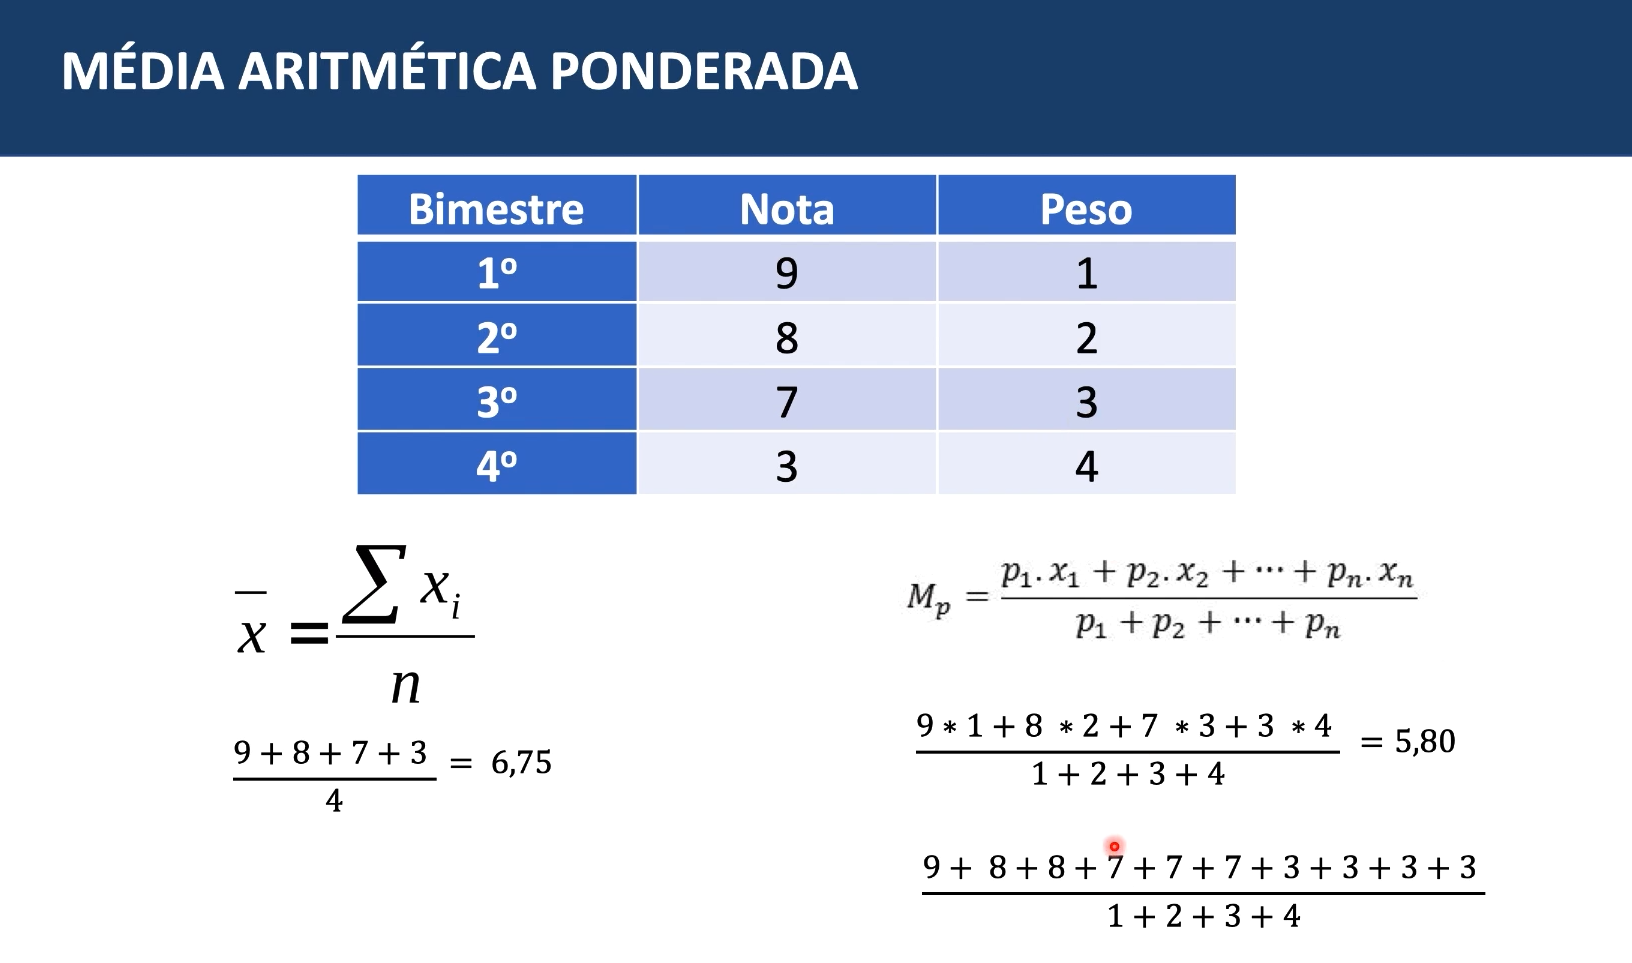

In [124]:
notas = np.array([9,8,7,3])
pesos = np.array([1,2,3,4])

media_ponderada = (notas * pesos).sum() / pesos.sum()
media_ponderada

np.float64(5.8)

## Média Aritmética, Moda e Mediana - Dados Agrupados

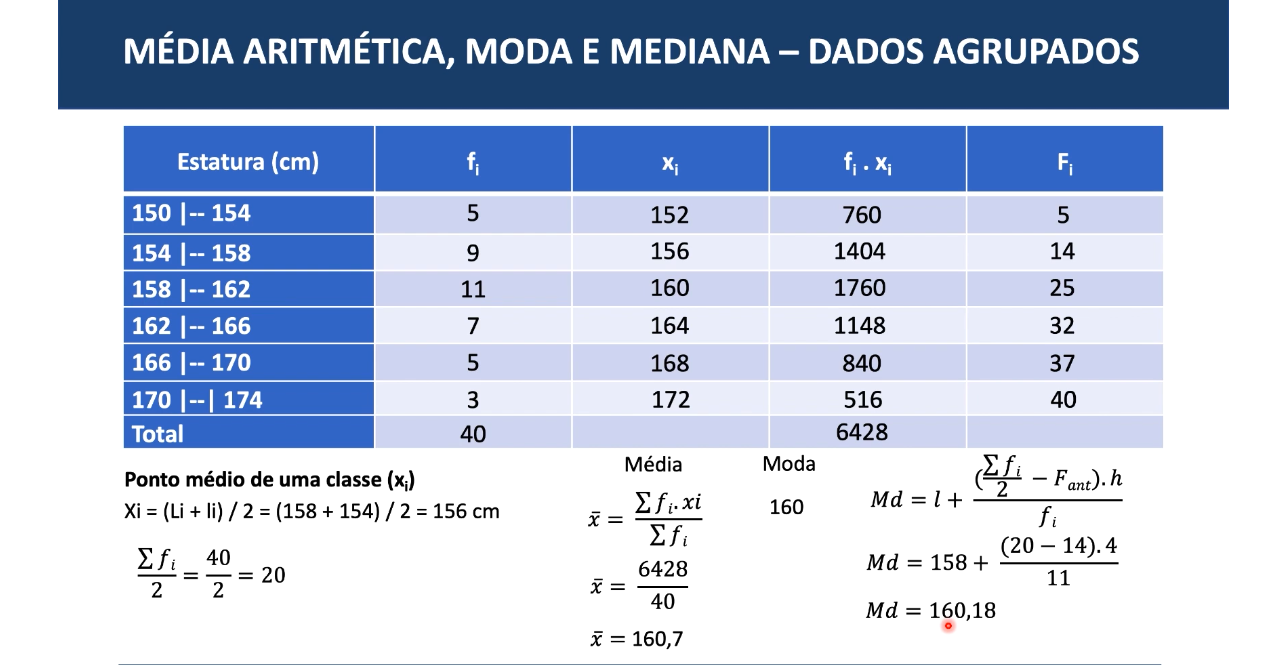

In [125]:
dados = {'inferior' : [150, 154, 158, 162, 166, 170],
         'superior' : [154, 158, 162, 166, 170, 174],
         'fi' : [5, 9, 11, 7, 5, 3]}

dataset = pd.DataFrame(dados)
dataset

,inferior,superior,fi
0,150,154,5
1,154,158,9
2,158,162,11
3,162,166,7
4,166,170,5
5,170,174,3


In [126]:
dataset['xi'] = (dataset['superior'] + dataset['inferior']) / 2 
dataset

,inferior,superior,fi,xi
0,150,154,5,152.0
1,154,158,9,156.0
2,158,162,11,160.0
3,162,166,7,164.0
4,166,170,5,168.0
5,170,174,3,172.0


In [127]:
dataset['fi.xi'] = dataset['fi'] * dataset['xi']
dataset

,inferior,superior,fi,xi,fi.xi
0,150,154,5,152.0,760.0
1,154,158,9,156.0,1404.0
2,158,162,11,160.0,1760.0
3,162,166,7,164.0,1148.0
4,166,170,5,168.0,840.0
5,170,174,3,172.0,516.0


In [128]:
dataset['Fi'] = 0
dataset

,inferior,superior,fi,xi,fi.xi,Fi
0,150,154,5,152.0,760.0,0
1,154,158,9,156.0,1404.0,0
2,158,162,11,160.0,1760.0,0
3,162,166,7,164.0,1148.0,0
4,166,170,5,168.0,840.0,0
5,170,174,3,172.0,516.0,0


In [129]:
frequencia_acumulada = []
somatorio = 0
for _,linha in dataset.iterrows():
    #print(linha['inferior'])
    somatorio += linha['fi']
    frequencia_acumulada.append(somatorio)

In [130]:
somatorio, frequencia_acumulada

(np.float64(40.0),
 [np.float64(5.0),
  np.float64(14.0),
  np.float64(25.0),
  np.float64(32.0),
  np.float64(37.0),
  np.float64(40.0)])

In [131]:
dataset['Fi'] = frequencia_acumulada
dataset

,inferior,superior,fi,xi,fi.xi,Fi
0,150,154,5,152.0,760.0,5.0
1,154,158,9,156.0,1404.0,14.0
2,158,162,11,160.0,1760.0,25.0
3,162,166,7,164.0,1148.0,32.0
4,166,170,5,168.0,840.0,37.0
5,170,174,3,172.0,516.0,40.0


In [132]:
# Média Aritmética dados agrupados
dataset['fi.xi'].sum() / dataset['fi'].sum()

np.float64(160.7)

In [133]:
# Moda dados agrupados
dataset[dataset['fi'] == dataset['fi'].max()]['xi'].values[0]

np.float64(160.0)

In [134]:
# Mediana
dataset

,inferior,superior,fi,xi,fi.xi,Fi
0,150,154,5,152.0,760.0,5.0
1,154,158,9,156.0,1404.0,14.0
2,158,162,11,160.0,1760.0,25.0
3,162,166,7,164.0,1148.0,32.0
4,166,170,5,168.0,840.0,37.0
5,170,174,3,172.0,516.0,40.0


In [135]:
fi_2 = dataset['fi'].sum() / 2

In [136]:
limite_inferior, frequencia_classe, id_frequencia_anterior = 0,0,0

In [137]:
for linha in dataset.iterrows():
    limite_inferior = linha[1]['inferior']
    frequencia_classe = linha[1]['fi']
    id_frequencia_anterior = linha[0]
    if linha[1]['Fi'] > fi_2:
        id_frequencia_anterior -= 1
        break

In [138]:
limite_inferior, frequencia_classe, id_frequencia_anterior

(np.float64(158.0), np.float64(11.0), 1)

In [139]:
Fi_anterior = dataset.iloc[[id_frequencia_anterior]]['Fi'].values[0]
Fi_anterior

np.float64(14.0)

In [140]:
mediana = limite_inferior + ((fi_2 - Fi_anterior) * 4) / frequencia_classe
mediana

np.float64(160.1818181818182)

## Media geométrica, harmônica e quadrática

In [146]:
dados = np.array([150, 151, 152, 152, 153, 154, 155, 155, 155, 155, 156, 156, 156,
       157, 158, 158, 160, 160, 160, 160, 160, 161, 161, 161, 161, 162,
       163, 163, 164, 164, 164, 165, 166, 167, 168, 168, 169, 170, 172,
       173])


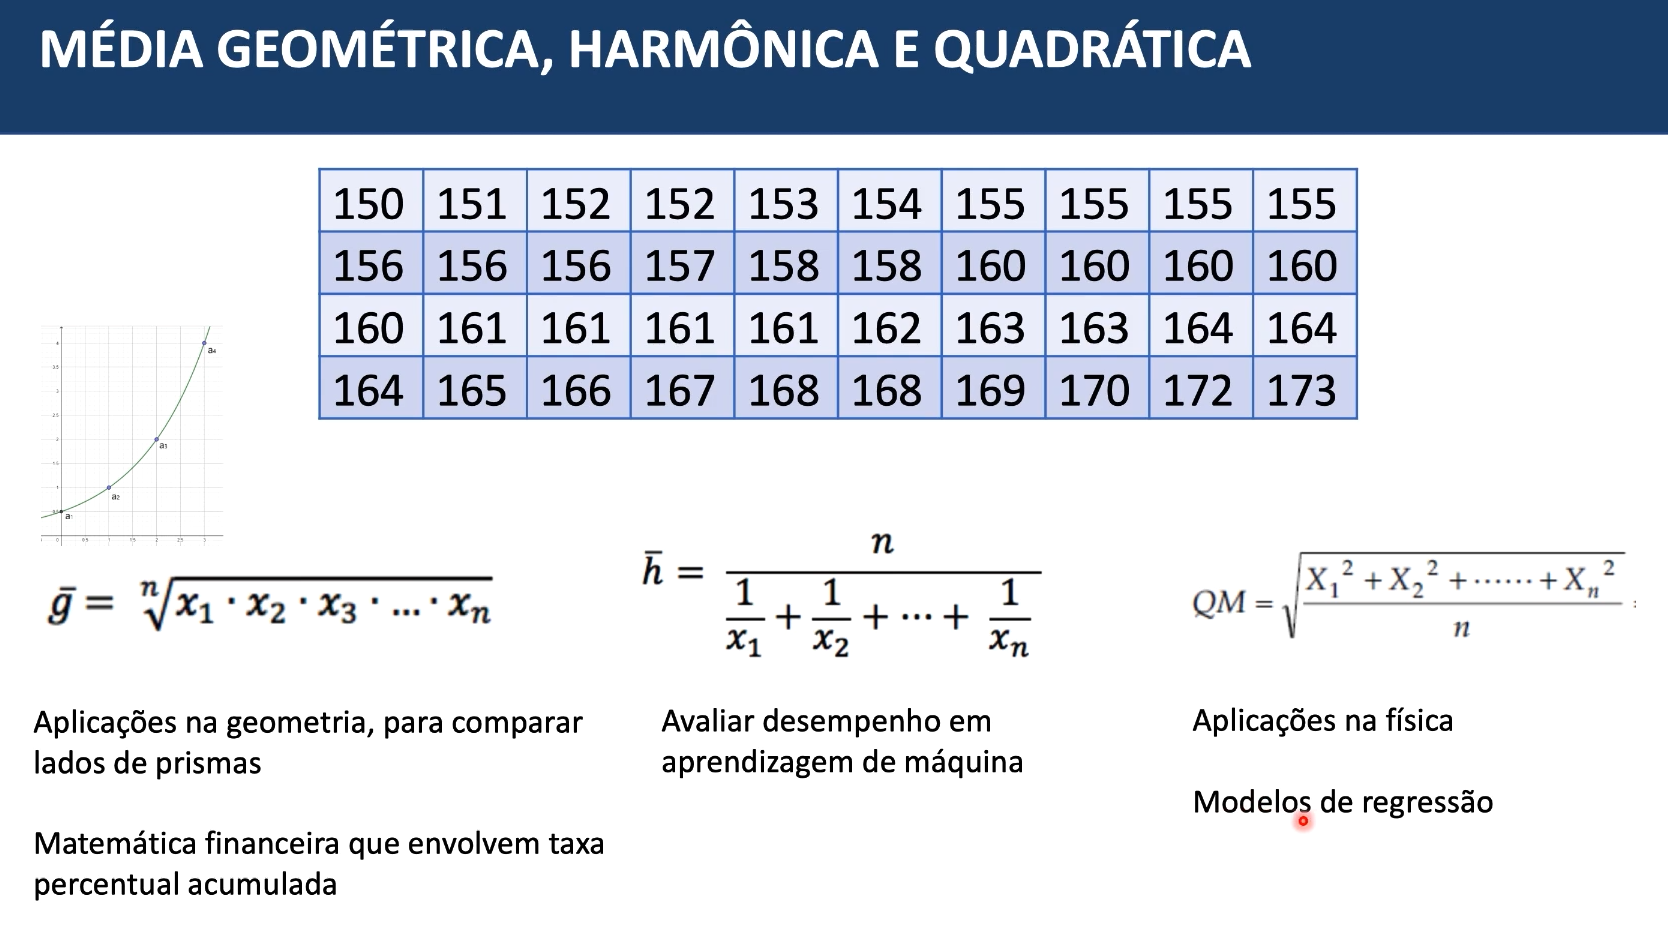

In [141]:
from scipy.stats.mstats import gmean

In [ ]:

gmean(dados)

np.float64(160.26958390038905)

## Média Harmônica

In [145]:
from scipy.stats.mstats import hmean

hmean(dados)

np.float64(160.1647194799467)

## Média Quadrática

In [149]:
def quadratic_func(dados):
    return math.sqrt(sum(n * n for n in dados) / len(dados))

In [150]:
quadratic_func(dados)

160.48091786876097